# **PROJECT CAPSTONE: DETECTION D'ATTAQUES DE CYBERSECURITE IDS**

# **ETAPE 0: IMPORTATION DES LIBRAIRIES**

In [4]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {0.1} IMPORTATION DES LIBRIARIES                                               #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

import gdown #!pip install gdown car nos donnees sont sur google drive
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import time
from sklearn.metrics import confusion_matrix, classification_report
import joblib
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


# **ETAPE 1: PREPARATION DES DONNEES**

In [5]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {1.1} CHARGEMENT DES DONNEES                                                   #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# Pour le chemin relatif pour stocker les donnees pour travailler (A MODIFIER TOUJOURS SI BESOIN DE TRAVAILLER SUR LE PROJECT)
DATA_DIR = Path("/") # Chemin a changer
DATA_DIR.mkdir(exist_ok=True)

# Pour la liste des fichiers Google Drive (IDs) que nous avons reccupere dans les liens
file_ids = [
    "1yeaLeHPq6kiPCQeHrA0E8IXV5jKTuIur",
    "1cPQyVex5SNYi3lb4prxxeHRHjDI_2fyJ",
    "1V9jv2-7lhDQirwzzKLbPmfFk3IA8p49E",
    "1u2PoxIwP9A9vzKG-4xLIzY4RNuc70Gin",
    "1yWAzTGzhO6v5XsgGrup6ECACMsKDuoGv",
    "1cUsqRX1D_R2kdlGddNkjtA7U5DdFaW7Y",
    "1RrTLvR1rSULSyWOjSmd1IWun3bNo0UnW",
    "1g6LPnI1KSG7oc-4zmc3pBcuQcPN_AvE9",
]

# Pour télécharger les fichiers
file_paths = []

for file_id in file_ids:
    url = f"https://drive.google.com/uc?id={file_id}"
    output_path = DATA_DIR / f"{file_id}.csv"
    gdown.download(url, str(output_path), quiet=False)
    file_paths.append(output_path)

print(f"{len(file_paths)} fichiers chargés avec succès.")

Downloading...
From (original): https://drive.google.com/uc?id=1yeaLeHPq6kiPCQeHrA0E8IXV5jKTuIur
From (redirected): https://drive.google.com/uc?id=1yeaLeHPq6kiPCQeHrA0E8IXV5jKTuIur&confirm=t&uuid=967eb173-cade-4ca0-8653-03534bb843aa
To: /1yeaLeHPq6kiPCQeHrA0E8IXV5jKTuIur.csv
100%|██████████| 225M/225M [00:06<00:00, 37.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1cPQyVex5SNYi3lb4prxxeHRHjDI_2fyJ
From (redirected): https://drive.google.com/uc?id=1cPQyVex5SNYi3lb4prxxeHRHjDI_2fyJ&confirm=t&uuid=4845c362-6a95-4ba9-ae48-8e8545ab395d
To: /1cPQyVex5SNYi3lb4prxxeHRHjDI_2fyJ.csv
100%|██████████| 135M/135M [00:02<00:00, 49.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1V9jv2-7lhDQirwzzKLbPmfFk3IA8p49E
To: /1V9jv2-7lhDQirwzzKLbPmfFk3IA8p49E.csv
100%|██████████| 52.0M/52.0M [00:00<00:00, 116MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1u2PoxIwP9A9vzKG-4xLIzY4RNuc70Gin
To: /1u2PoxIwP9A9vzKG-4xLIzY4RNuc70Gin.csv
100%|██████████| 83.1M/83.1M [00:00

8 fichiers chargés avec succès.


In [6]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {1.2} CHARGEMENT DES DONNEES ET FUSION                                         #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# Pour charger chaque fichier CSV dans une liste
dfs = [pd.read_csv(path) for path in file_paths]

# Pour Fusionner tous les fichiers en un seul DataFrame
df = pd.concat(dfs, ignore_index=True)

# Un aperçu des données
df.head(20)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
5,389,433,11,4,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
6,88,1088,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
7,80,579225,132,150,160,320799,160,0,1.212121,13.926212,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
8,49666,3,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
9,49413,4,3,0,18,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
# Pour voir la stucture de mes données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [8]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {1.3} NETTOYAGE ET OPTIMISATION MÉMOIRE                                        #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# Pour la suppression des espaces dans les noms de colonnes
df.columns = df.columns.str.strip()

# Pour la suppression des doublons
print(f"Doublons avant : {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Doublons après : {df.duplicated().sum()}")

# Pour la gestion des valeurs infinies et manquantes
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# On remplit les NaN par la médiane
df.fillna(df.median(numeric_only=True), inplace=True)

# Pour l'optimisation des types, un (Downcasting) pour économiser la RAM
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = df[col].astype('float32')
    if df[col].dtype == 'int64':
        df[col] = df[col].astype('int32')

print("Nettoyage et optimisation terminés.")
df.info()

Doublons avant : 308381
Doublons après : 0
Nettoyage et optimisation terminés.
<class 'pandas.core.frame.DataFrame'>
Index: 2522362 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int32  
 1   Flow Duration                int32  
 2   Total Fwd Packets            int32  
 3   Total Backward Packets       int32  
 4   Total Length of Fwd Packets  int32  
 5   Total Length of Bwd Packets  int32  
 6   Fwd Packet Length Max        int32  
 7   Fwd Packet Length Min        int32  
 8   Fwd Packet Length Mean       float32
 9   Fwd Packet Length Std        float32
 10  Bwd Packet Length Max        int32  
 11  Bwd Packet Length Min        int32  
 12  Bwd Packet Length Mean       float32
 13  Bwd Packet Length Std        float32
 14  Flow Bytes/s                 float32
 15  Flow Packets/s               float32
 16  Flow IAT Mean                float32
 17  Flow IAT S

In [9]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {1.4} ENCODAGE ET PRÉPARATION DES VARIABLES                                    #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# Pour la transformation des noms d'attaques en numéros
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

# On définit X (données) et y (ce qu'on cherche : l'attaque)
X = df.drop('Label', axis=1)
y = df['Label']

# Pour la séparation : 80% pour apprendre, 20% pour tester
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pour l'affichage
print(f"Classes détectées : {list(le.classes_)}")

Classes détectées : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [10]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {1.5} NETTOYAGE CYBER : ÉLIMINATION DU DATA LEAKAGE                            #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# On retire les colonnes d'identification pour forcer l'IA à être comportementale
cols_to_drop = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Timestamp']

# On ne supprime que si elles existent dans le DataFrame
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print(f"Colonnes supprimées. Nouvelle dimension : {df.shape}")

Colonnes supprimées. Nouvelle dimension : (2522362, 79)


/tmp/ipykernel_7370/2461495497.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y_true_names, palette='magma', order=pd.Series(y_true_names).value_counts().index)


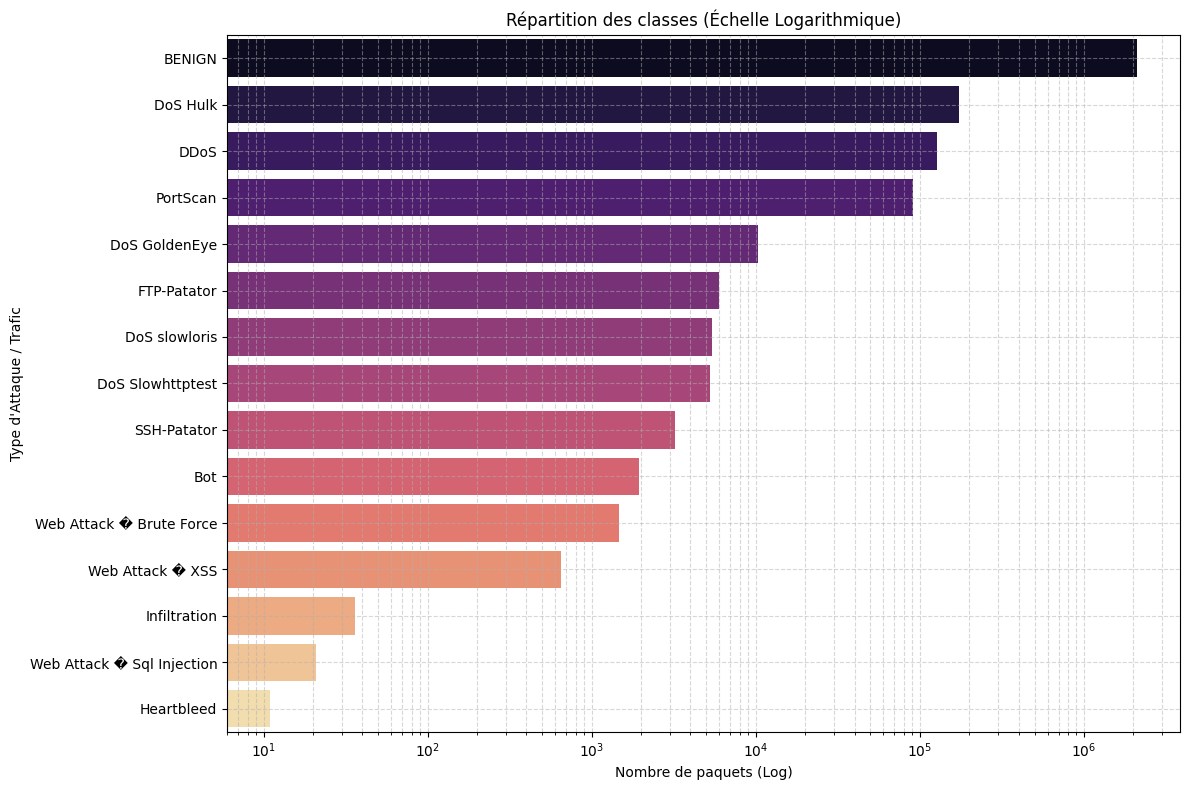

In [11]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {1.6} ANALYSE DÉTAILLÉE DES CLASSES (ÉCHELLE LOG)                              #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

plt.figure(figsize=(12, 8))

# On récupère les vrais noms grâce à l'inverse_transform
y_true_names = le.inverse_transform(df['Label'])

# Pour la création du graphique horizontal pour la lisibilité des noms
sns.countplot(y=y_true_names, palette='magma', order=pd.Series(y_true_names).value_counts().index)

# Pour voir l'échelle Logarithmique pour voir les attaques rares
plt.xscale('log')

plt.title("Répartition des classes (Échelle Logarithmique)")
plt.xlabel("Nombre de paquets (Log)")
plt.ylabel("Type d'Attaque / Trafic")
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {2.1} SMART SAMPLING (200k) : PROTECTION DES CLASSES MINORITAIRES              #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# On identifie les classes critiques (celles qui ont très peu d'exemples)
# et On garde 100% de ces classes pour ne pas perdre l'intelligence du modèle
class_counts = df['Label'].value_counts()
rare_threshold = 50
rare_classes = class_counts[class_counts < rare_threshold].index

df_rare = df[df['Label'].isin(rare_classes)]
df_common = df[~df['Label'].isin(rare_classes)]

# On complète avec le trafic commun pour atteindre 200 000 lignes au total
needed = 1000000 - len(df_rare)
df_common_sample, _ = train_test_split(df_common, train_size=needed, stratify=df_common['Label'], random_state=42)

# On fusionne pour avoir notre dataset de travail
df_small = pd.concat([df_rare, df_common_sample])

# Maintenant, le split Train/Test passera car on a sécurisé les échantillons
X_small = df_small.drop('Label', axis=1)
y_small = df_small['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

print(f"Échantillonnage intelligent terminé : {len(df_small)} lignes.")
print(f"Classes rares préservées intégralement : {list(le.inverse_transform(rare_classes))}")

Échantillonnage intelligent terminé : 200000 lignes.
Classes rares préservées intégralement : ['Infiltration', 'Web Attack � Sql Injection', 'Heartbleed']


In [13]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {3.0} STANDARDISATION (MISE À L'ÉCHELLE POUR L'IA)                            #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# On initialise le scaler
scaler = StandardScaler()

# On calcule les paramètres sur le Train uniquement (fit_transform)
# Et on applique simplement sur le Test (transform) pour éviter la triche (leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardisation terminée sur les 200 000 lignes.")
print(f"Moyenne après scaling (proche de 0) : {X_train_scaled.mean():.2f}")

Standardisation terminée sur les 200 000 lignes.
Moyenne après scaling (proche de 0) : 0.00


In [14]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {4.0} ÉQUILIBRAGE SMOTE AVEC LABELS CLAIRS                                   #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# 1. Initialisation du SMOTE
# k_neighbors=1 est une sécurité au cas où une classe rare n'aurait que 2 exemplaires
smote = SMOTE(random_state=42, k_neighbors=1)

print("Équilibrage SMOTE en cours sur 200k lignes...")
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 2. Traduction immédiate des chiffres en noms pour la clarté
y_train_res_named = le.inverse_transform(y_train_res)

print(f"Équilibrage terminé avec succès.")
print(f"Volume total après SMOTE : {len(X_train_res)} lignes")
print("-" * 50)
print("Répartition finale par attaque :")
print(pd.Series(y_train_res_named).value_counts())

Équilibrage SMOTE en cours sur 200k lignes...
Équilibrage terminé avec succès.
Volume total après SMOTE : 1994160 lignes
--------------------------------------------------
Répartition finale par attaque :
BENIGN                        132944
PortScan                      132944
DoS Hulk                      132944
DDoS                          132944
Web Attack � Sql Injection    132944
DoS Slowhttptest              132944
Infiltration                  132944
FTP-Patator                   132944
DoS slowloris                 132944
DoS GoldenEye                 132944
Web Attack � Brute Force      132944
SSH-Patator                   132944
Bot                           132944
Heartbleed                    132944
Web Attack � XSS              132944
Name: count, dtype: int64


In [ ]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {5.0} ENTRAÎNEMENT DU MODÈLE : RANDOM FOREST CLASSIFIER                       #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# On crée le modèle
# n_estimators=100 : un bon équilibre entre précision et vitesse
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Entraînement du Random Forest en cours sur les données SMOTE...")
start_time = time.time()

# On entraîne sur les données ÉQUILIBRÉES (resampled)
rf_model.fit(X_train_res, y_train_res)

end_time = time.time()
print(f"Entraînement terminé en {end_time - start_time:.2f} secondes.")

Entraînement du Random Forest en cours sur les données SMOTE...


In [ ]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {6.0} ÉVALUATION : PRÉDICTION ET MATRICE DE CONFUSION                         #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# 1. Prédiction sur le jeu de test
y_pred = rf_model.predict(X_test_scaled)

# 2. Génération du rapport texte (Précision, Recall, F1-Score)
# On utilise target_names pour avoir les vrais noms d'attaques
print("RAPPORT DE CLASSIFICATION :")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 3. Création de la Matrice de Confusion visuelle
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matrice de Confusion : Prédictions vs Réalité")
plt.ylabel('Vraie Attaque')
plt.xlabel('Attaque Prédite')
plt.show()

In [ ]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {7.0} EXPLICABILITÉ : FEATURES IMPORTANCE (L'ARGUMENT FINAL)                 #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# On récupère l'importance de chaque colonne
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]  # On prend les 10 meilleures

plt.figure(figsize=(10, 6))
plt.title("Top 10 des caractéristiques déterminantes pour l'IDS")
plt.barh(range(len(indices)), importances[indices], color='crimson', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importance Relative')
plt.show()

In [ ]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {8.0} SAUVEGARDE FINALE DU PROJET (EXPORT)                                   #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# Sauvegarde du modèle Random Forest
joblib.dump(rf_model, 'ids_random_forest_v1.pkl')

# Sauvegarde du Scaler (indispensable pour les futures données)
joblib.dump(scaler, 'ids_scaler.pkl')

# Sauvegarde du LabelEncoder (pour traduire les résultats)
joblib.dump(le, 'ids_label_encoder.pkl')

print("Modèle et outils sauvegardés avec succès !")


In [ ]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {9.0} SIMULATION DE DÉTECTION EN TEMPS RÉEL                                    #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# On charge les outils qu'on vient de sauvegarder
loaded_rf = joblib.load('ids_random_forest_v1.pkl')
loaded_scaler = joblib.load('ids_scaler.pkl')

# On prend une ligne au hasard dans le dataset d'origine (X_test)
sample_idx = np.random.randint(len(X_test))
sample_data = X_test.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]

# Prétraitement (Scaling) comme en conditions réelles
sample_scaled = loaded_scaler.transform(sample_data)

# Prédiction
prediction_idx = loaded_rf.predict(sample_scaled)
prediction_name = le.inverse_transform(prediction_idx)[0]
real_name = le.inverse_transform([true_label])[0]

print(f"Analyse du flux réseau n°{sample_idx}...")
print(f"Résultat de l'IA : {'ALERTE : ' + prediction_name if prediction_name != 'BENIGN' else 'TRAFIC SAIN'}")
print(f"Vérité terrain   : {real_name}")

In [ ]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {10.0} COMPARATIF : DEEP LEARNING (MLP CLASSIFIER)                           #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# On définit un réseau avec 2 couches cachées de 50 neurones chacune
# max_iter=20 pour que ça aille vite pour le test
mlp_model = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=20, random_state=42, verbose=True)

print("Entraînement du Réseau de Neurones (Deep Learning) en cours...")
mlp_model.fit(X_train_res, y_train_res)

# Évaluation rapide
mlp_score = mlp_model.score(X_test_scaled, y_test)
rf_score = rf_model.score(X_test_scaled, y_test)

print("-" * 30)
print(f"Score Deep Learning  : {mlp_score:.4f}")

In [ ]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {12.0} LE TROISIÈME CHAMPION : XGBOOST CLASSIFIER                              #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

print("Entraînement de XGBoost en cours...")

# Configuration
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    tree_method='hist'
)

# Entraînement
xgb_model.fit(X_train_res, y_train_res)

# Prédiction et calcul du score
y_pred_xgb = xgb_model.predict(X_test_scaled)
xgb_score = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Score : {xgb_score*100:.2f}%")
print("\nRAPPORT DE CLASSIFICATION XGBOOST :")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

In [ ]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {13.0} LE PODIUM FINAL : RF vs MLP vs XGB                                      #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# Préparation des données de comparaison
final_results = pd.DataFrame({
    'Modèle': ['Random Forest', 'Deep Learning (MLP)', 'XGBoost'],
    'Accuracy': [rf_score, mlp_score, xgb_score]
})

# On trie pour avoir le champion en premier
final_results = final_results.sort_values(by='Accuracy', ascending=False)

# 2. Graphique (Correction de la syntaxe Seaborn)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# On assigne 'Modèle' à 'hue' pour éviter le warning
ax = sns.barplot(x='Modèle', y='Accuracy', data=final_results, hue='Modèle', palette='viridis', legend=False)

# Ajout des labels de pourcentage
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, fontweight='bold', xytext=(0, 10),
                textcoords='offset points')

plt.title("Duel Final : Comparaison des 3 Architectures IDS", fontsize=15)
plt.ylim(0.9, 1.05)
plt.ylabel("Score d'Accuracy")
plt.show()

# Sauvegarde du nouveau champion officiel
joblib.dump(xgb_model, 'ids_xgboost_winner.pkl')

print("Champion (XGBoost) sauvegardé sous 'ids_xgboost_winner.pkl'")
print("\nCLASSEMENT FINAL DU CAPSTONE :")
print(final_results.to_string(index=False))

In [ ]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {14.0} BENCHMARK : VITESSE D'INFÉRENCE (TEMPS RÉEL)                          #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# On prend un échantillon de 10 000 paquets
sample_inference = X_test_scaled[:10000]

# Test pour Random Forest
start_rf = time.time()
rf_model.predict(sample_inference)
end_rf = time.time()
rf_time = end_rf - start_rf

# Test pour XGBoost
start_xgb = time.time()
xgb_model.predict(sample_inference)
end_xgb = time.time()
xgb_time = end_xgb - start_xgb

print(f" Temps pour 10 000 paquets (Random Forest) : {rf_time:.4f} secondes")
print(f"Temps pour 10 000 paquets (XGBoost)       : {xgb_time:.4f} secondes")
print(f"Capacité de traitement : {int(10000/xgb_time)} paquets/seconde (XGBoost)")

In [ ]:
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ
#ϟ {15.0} MATRICE DE CONFUSION NORMALISÉE (CHAMPION XGBOOST)                    #ϟ
#ϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟϟ

# On génère la matrice de confusion pour le gagnant (XGBoost)
cm = confusion_matrix(y_test, y_pred_xgb)

# On normalise par ligne (True Labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(15, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title("Matrice de Confusion Normalisée (%) - Champion XGBoost")
plt.ylabel('Vraie Attaque')
plt.xlabel('Attaque Prédite')
plt.show()